In [9]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report 
import os, cv2, numpy as np

In [5]:
os.getcwd()

'c:\\Users\\na062\\Desktop\\dacon\\image_icon_25_03'

In [ ]:
def get_imageandlabel(file_name, data_dir):
    '''
    input: 이미지 경로 중 마지막 파일명 
    이름명: TRAIN_번호_라벨.png
    output: 이미지 경로, 라벨
    '''
    path = os.path.join(data_dir, file_name) # 이미지 경로
    name = file_name.replace('.png', '') # png 확장자 제거
    class_name = int(name.split('_')[-1]) # 라벨
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # 이미지 불러오기
    return image, class_name

### 1. RAW TRAINING IMAGE 담기

In [21]:
train_dir = 'data/train'
data_dir = os.path.join(os.getcwd(), train_dir) # 이미지 경로
image_list = []
label_list = []
for file_name in os.listdir(data_dir):
    image, class_name = get_imageandlabel(file_name, data_dir)
    image_list.append(image)
    label_list.append(class_name)
len(image_list), len(label_list) , image_list[0].shape

(769, 769, (32, 32))

#### 1.1. 데이터 시각화 

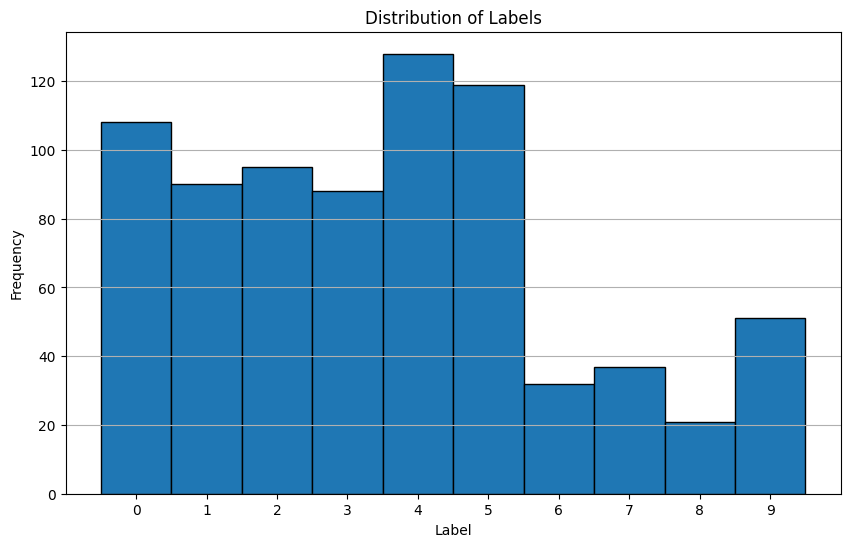

In [29]:
import matplotlib.pyplot as plt

# label 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(label_list, bins=np.arange(min(label_list), max(label_list) + 2) - 0.5, edgecolor='black')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Distribution of Labels')
plt.xticks(np.arange(min(label_list), max(label_list) + 1))
plt.grid(axis='y')
plt.show()

### 2. Augmented Train 이미지 담기 

In [22]:
data_dir = os.path.join(os.getcwd(), 'data/train_data') # 이미지 경로
augmented_image_list = []
augmented_label_list = []
for file_name in os.listdir(data_dir):
    image, class_name = get_imageandlabel(file_name, data_dir)
    augmented_image_list.append(image)
    augmented_label_list.append(class_name)
len(augmented_image_list), len(augmented_label_list) , augmented_image_list[0].shape


(25600, 25600, (32, 32))

### 3. 모델 두개 만들기 

#### 3.1. 전통적 방식 (HOG + SVM)

In [30]:
def feature_extraction(image_list):
    hog_feature_list = []
    for image in image_list:
        hog_feature = hog(image, orientations=8, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
        hog_feature_list.append(hog_feature)
    return hog_feature_list

In [31]:
import numpy as np
from collections import Counter
from sklearn.neighbors import NearestNeighbors

def SMOTE(X, y, k=5):
    X = np.array(X)
    y = np.array(y)
    
    # 클래스별 개수 확인
    counter = Counter(y)
    max_count = max(counter.values())
    
    X_new = [X.copy()]
    y_new = [y.copy()]
    
    for cls in counter:
        n_samples = counter[cls]
        n_to_generate = max_count - n_samples
        if n_to_generate == 0:
            continue

        # 해당 클래스 데이터만 추출
        X_cls = X[y == cls]
        
        # 최근접 이웃 모델 생성
        nn = NearestNeighbors(n_neighbors=min(k, len(X_cls)))
        nn.fit(X_cls)

        synthetic_samples = []
        for _ in range(n_to_generate):
            idx = np.random.randint(0, len(X_cls))
            x_i = X_cls[idx]
            neighbors = nn.kneighbors([x_i], return_distance=False)[0]
            neighbor = X_cls[np.random.choice(neighbors[1:])]  # 자기 자신 제외
            diff = neighbor - x_i
            gap = np.random.rand()
            synthetic = x_i + gap * diff
            synthetic_samples.append(synthetic)

        X_new.append(np.array(synthetic_samples))
        y_new.append(np.array([cls] * n_to_generate))

    X_resampled = np.vstack(X_new)
    y_resampled = np.hstack(y_new)

    return X_resampled, y_resampled


In [32]:
featrues = feature_extraction(image_list)

# train test split
X_train, X_test, y_train, y_test = train_test_split(featrues, label_list, test_size=0.2, random_state=42)

# SMOTE
X_train, y_train = SMOTE(X_train, y_train)
# train
clf = SVC(kernel='rbf', C=10, gamma=0.01,class_weight='balanced')
clf.fit(X_train, y_train)

# test
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        24
           1       0.71      0.86      0.77        14
           2       0.79      0.86      0.83        22
           3       0.92      1.00      0.96        22
           4       0.88      0.88      0.88        24
           5       0.84      0.73      0.78        22
           6       0.80      0.57      0.67         7
           7       1.00      1.00      1.00         7
           8       1.00      0.67      0.80         3
           9       1.00      1.00      1.00         9

    accuracy                           0.86       154
   macro avg       0.88      0.84      0.86       154
weighted avg       0.87      0.86      0.86       154



#### 3.2. CNN 모델  

In [ ]:
import torch 
import torch.nn as nn
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # input: (1, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                 # (32, 16, 16)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # (64, 8, 8)
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)               # 10 클래스
        )
    
    def forward(self, x):
        return self.net(x)
